# Testing our equation to La Jara data 

In [3]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error
import itertools

### Model Functions

In [4]:
def evolve_tauc_tc(
    tau_star,           # array of Shields stress τ*(t)
    dt,                 # timestep between τ* samples
    tau_c_min,          # minimum τ*c global
    tau_c_max,          # maximum τ*c global
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    multiplicative_factor=1, # factor to adjust k values (e.g., for sensitivity testing)
    A=0.2924,
    B=8.6866
):

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c, τ*c_eq, and k array
    n = len(tau_star_vals)
    tau_c = np.full(n, np.nan, dtype=float)  # nan means τ*c is undefined (e.g., during gaps)
    tau_c_pot = np.full(n, np.nan, dtype=float)
    k_array = np.full(n, np.nan, dtype=float)
    tauc_ratio = np.full(n, np.nan, dtype=float)
    tau_conv_array = np.full(n, np.nan, dtype=float)

    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True

    i = 0
    while i < n-1:
        # determine current τ*
        t = tau_star_vals[i]  # current τ*

        # k equation parameters from flume data
        k = A * (t / tau_c_max) ** B

        # initialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False
        else:
            tau_c_current = tau_c[i]

        # calculate transport capacity 
        tc = t/tau_c_current  # transport capacity
        tauc_ratio[i] = tc

        # calculate potential τ*c based on current τ*/τ*c
        ks = 50
        xs = 0.79
        kw = 3.7
        if tc <= 1:
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (tc - xs)))
            tau_pot = max(tau_c_current, tau_conv)  # τ*c cannot decrease below current value if τ* is low
            tau_pot_pure = tau_conv
        else:  # otherwise, equilibrium is given by the weakening function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * (tc) ** (-kw)
            tau_pot = tau_conv
            tau_pot_pure = tau_conv

        k_array[i] = k
        tau_c_pot[i] = tau_pot_pure
        tau_conv_array[i] = tau_pot

        # evolve τ*c with new equation
        tau_c[i+1] = tau_conv_array[i] - (tau_conv_array[i] - tau_c[i]) * np.exp(-k * multiplicative_factor * dt)
        #print('tauc at time:', i, 'is', tau_c[i], '. tau/tauc', tauc_ratio[i], 'and tau_pot is', tau_c_pot[i], 'with k', k_array[i])
        i += 1

    return tau_c, k_array, tau_c_pot, tauc_ratio

parameter calibration 

In [5]:
def calibrate_parameters(
    tau_star,
    event_indices,      # indices of event start times
    tau_c_obs,          # observed τ*c at events
    dt,
    tau_c_max,
    tau_c_min,
    A_vals,             # candidate values for parameter A
    B_vals,             # candidate values for parameter B
):
    
    """
    Grid-search calibration of the model using mean absolute error (MAE).
    """
    results = []
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    
    # iterate through minimum τ*c values, and A and B parameters
    for a_idx, A in enumerate(A_vals):
        print(f"Testing A = {A:.6e} ({a_idx + 1}/{len(A_vals)})")
        for b_idx, B in enumerate(B_vals):
            print(f"Testing B = {B:.6e} ({b_idx + 1}/{len(B_vals)})")
            tau_c_model, *_ = evolve_tauc_tc(
                tau_star=tau_star,
                dt=dt,
                tau_c_min=tau_c_min,
                tau_c_max=tau_c_max,
                event_indices=event_indices,
                tau_c_obs=tau_c_obs,
                A=A,
                B=B,
            )

            # extract modeled τ*c at event starts
            if isinstance(tau_star, pd.Series):
                tau_c_series = pd.Series(tau_c_model, index=tau_star.index)
                tau_c_pred = tau_c_series.reindex(event_indices).to_numpy(dtype=float)
            else:
                event_pos = np.asarray(event_indices, dtype=int)
                tau_c_pred = np.asarray(tau_c_model, dtype=float)[event_pos]

            # calculate mean absolute error (paper uses MAE), and ignore NaNs
            mae = np.nanmean(np.abs(tau_c_pred - tau_c_obs_arr))
            results.append({
                "A": A,
                "B": B,
                "tau_c_min": tau_c_min,
                "MAE": mae
            })

    expected = len(A_vals) * len(B_vals)
    if len(results) != expected:
        raise RuntimeError(f"Expected {expected} calibration rows, got {len(results)}")

    return results

parameter ranges

In [6]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 100) # values evenly spaced on log scale
B_vals = np.linspace(1, 50, 50) # values from 0 to 10

### Testing Field Data

Import Data

In [28]:
# import data 
tau_star = pd.read_csv('../../../shear_stress_record/average_shear_stress_lajara_full.csv')
tauc_events = pd.read_csv('../field_data/tauc_events_exceedance_rising.csv', parse_dates=['datetime'], index_col='datetime')
# convert to datetime and set as index
tau_star['datetime'] = pd.to_datetime(tau_star['datetime']) 
tau_star = tau_star.set_index('datetime')
df_tau_resampled = tau_star.resample('1min').ffill()  # forwardfill to keep tau* constant during gaps
# create continuous 1-minute time index from first timestamp to last
continuous_index = pd.date_range(start=tau_star.index.min(), end=tau_star.index.max(), freq='1min')
# change column name to 'tau' for clarity
df_tau = tau_star.rename(columns={'shear_stress': 'tau'})
# delete everything before 2022-07-14 (we don't care about earlier times)
df_tau = df_tau[df_tau.index >= '2022-07-14 15:00']


print(f"Data gaps (NaNs): {df_tau['tau'].isna().sum().sum()}")
# show what dates are the data gaps
print("Data gaps (NaN indices):", df_tau[df_tau['tau'].isna()].index)

# convert tau to dimenstionless Shields stress τ*
rho_s = 2650.0  # sediment density, kg/m3
rho = 1000.0   # fluid density, kg/m3
g = 9.81       # gravitational acceleration, m/s2
d50 = 0.04364    # median grain diameter, m

df_tau['tau_star'] = df_tau['tau'] / ((rho_s - rho) * g * d50)

# build integer index mapping
time_to_index = pd.Series(
    np.arange(len(df_tau)), 
    index=df_tau.index
)
event_indices = time_to_index.loc[tauc_events.index].to_numpy() # integer indices of event times
tau_c_obs = tauc_events["tauc"].to_numpy() # observed τ*c values
tau_star = df_tau["tau_star"].to_numpy() # τ* time series array

# calculate dt in minutes (should be 15)
dt = (df_tau.index[1] - df_tau.index[0]).total_seconds() / 60
print(f"Calculated dt: {dt} minutes")

Data gaps (NaNs): 0
Data gaps (NaN indices): DatetimeIndex([], dtype='datetime64[ns]', name='datetime', freq=None)
Calculated dt: 15.0 minutes


Run Full La Jara Record

In [25]:
tauc_obs_lajara = tauc_events["tauc"].to_numpy()
# find min and max of τ*c observations 
tauc_min_lajara = 0.085
tauc_max_lajara = tauc_obs_lajara.max() * 1.01

In [26]:
tauc_min_lajara

0.085

#### First Iteration: dt=15

In [54]:
# start, stop, number of values
A_vals = np.logspace(-6, 0, 100) # values evenly spaced on log scale
B_vals = np.linspace(0, 50, 50) 
tauc_min_lajara = 0.08

In [56]:
calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/100)
Testing B = 0.000000e+00 (1/50)
Testing B = 1.020408e+00 (2/50)
Testing B = 2.040816e+00 (3/50)
Testing B = 3.061224e+00 (4/50)
Testing B = 4.081633e+00 (5/50)
Testing B = 5.102041e+00 (6/50)
Testing B = 6.122449e+00 (7/50)
Testing B = 7.142857e+00 (8/50)
Testing B = 8.163265e+00 (9/50)
Testing B = 9.183673e+00 (10/50)
Testing B = 1.020408e+01 (11/50)
Testing B = 1.122449e+01 (12/50)
Testing B = 1.224490e+01 (13/50)
Testing B = 1.326531e+01 (14/50)
Testing B = 1.428571e+01 (15/50)
Testing B = 1.530612e+01 (16/50)
Testing B = 1.632653e+01 (17/50)
Testing B = 1.734694e+01 (18/50)
Testing B = 1.836735e+01 (19/50)
Testing B = 1.938776e+01 (20/50)
Testing B = 2.040816e+01 (21/50)
Testing B = 2.142857e+01 (22/50)
Testing B = 2.244898e+01 (23/50)
Testing B = 2.346939e+01 (24/50)
Testing B = 2.448980e+01 (25/50)
Testing B = 2.551020e+01 (26/50)
Testing B = 2.653061e+01 (27/50)
Testing B = 2.755102e+01 (28/50)
Testing B = 2.857143e+01 (29/50)
Testing B = 2.95918

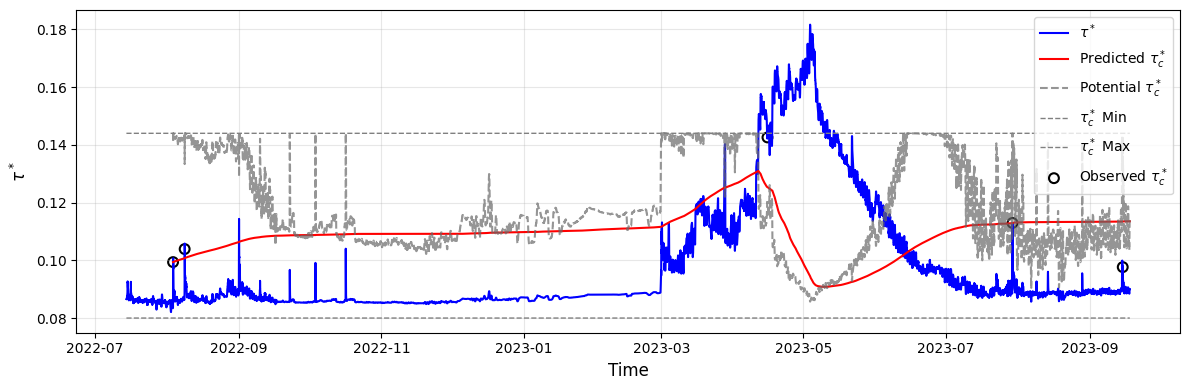

In [57]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=15, # 15 minute timestep
    tau_c_min=best["tau_c_min"],
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [best["tau_c_min"]]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Sensitivity Analysis

Best MAE: 0.007245
10% threshold (<=): 0.007970
Parameter sets within threshold: 12 / 5000


,tau_c_min,A,B,MAE
0,0.08,0.000057,5.102041,0.007245
1,0.08,0.000066,5.102041,0.007431
2,0.08,0.000050,5.102041,0.007539
3,0.08,0.000087,6.122449,0.007628
4,0.08,0.000076,6.122449,0.007737
5,0.08,0.000043,4.081633,0.007753
6,0.08,0.000050,4.081633,0.007761
7,0.08,0.000076,5.102041,0.007775
8,0.08,0.000038,4.081633,0.007820
9,0.08,0.000043,5.102041,0.007862


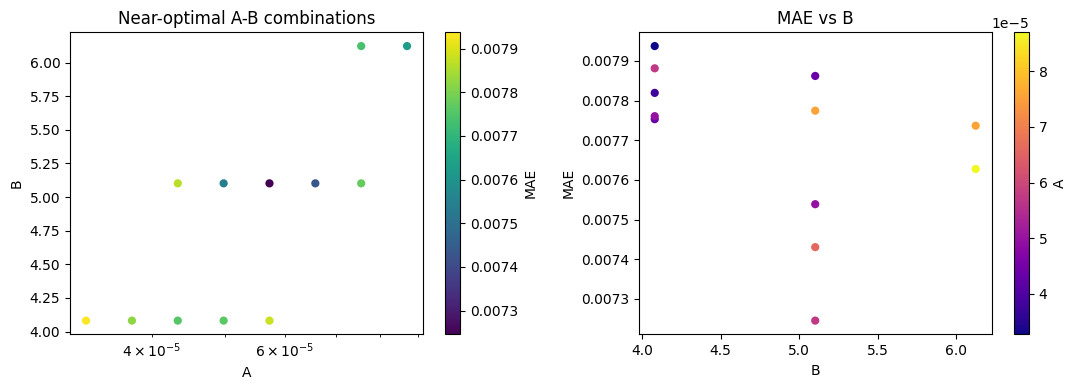

In [58]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.10

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "changing_tcmin/tc_min_0.08.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["B"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("B")
    axes[0].set_title("Near-optimal A-B combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["B"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("B")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs B")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

#### Second Iteration

In [54]:
# start, stop, number of values
A_vals = np.logspace(-6, -3, 40) # values evenly spaced on log scale
tauc_min_vals = np.linspace(0.05, 0.1, 25)

In [51]:
tauc_min_vals

array([0.05      , 0.05208333, 0.05416667, 0.05625   , 0.05833333,
       0.06041667, 0.0625    , 0.06458333, 0.06666667, 0.06875   ,
       0.07083333, 0.07291667, 0.075     , 0.07708333, 0.07916667,
       0.08125   , 0.08333333, 0.08541667, 0.0875    , 0.08958333,
       0.09166667, 0.09375   , 0.09583333, 0.09791667, 0.1       ])

In [52]:
B_vals

8.6866

In [53]:
A_vals

array([1.00000000e-06, 1.12533558e-06, 1.26638017e-06, 1.42510267e-06,
       1.60371874e-06, 1.80472177e-06, 2.03091762e-06, 2.28546386e-06,
       2.57191381e-06, 2.89426612e-06, 3.25702066e-06, 3.66524124e-06,
       4.12462638e-06, 4.64158883e-06, 5.22334507e-06, 5.87801607e-06,
       6.61474064e-06, 7.44380301e-06, 8.37677640e-06, 9.42668455e-06,
       1.06081836e-05, 1.19377664e-05, 1.34339933e-05, 1.51177507e-05,
       1.70125428e-05, 1.91448198e-05, 2.15443469e-05, 2.42446202e-05,
       2.72833338e-05, 3.07029063e-05, 3.45510729e-05, 3.88815518e-05,
       4.37547938e-05, 4.92388263e-05, 5.54102033e-05, 6.23550734e-05,
       7.01703829e-05, 7.89652287e-05, 8.88623816e-05, 1.00000000e-04])

In [56]:
calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min_vals=tauc_min_vals,
    A_vals=A_vals,
    B_vals=[B_vals],
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing tau_c_min = 5.000000e-02 (1/25)
Testing A = 1.000000e-06 (1/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.193777e-06 (2/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.425103e-06 (3/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.701254e-06 (4/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 2.030918e-06 (5/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 2.424462e-06 (6/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 2.894266e-06 (7/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 3.455107e-06 (8/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 4.124626e-06 (9/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 4.923883e-06 (10/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 5.878016e-06 (11/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 7.017038e-06 (12/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 8.376776e-06 (13/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.000000e-05 (14/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.193777e-05 (15/40)
Testing B = 8.686600e+00 (1/1)
Testing A

Sensitivity Analysis

Best MAE: 0.008970
10% threshold (<=): 0.010315
Parameter sets within threshold: 34 / 1000

Top 30 by MAE:


,tau_c_min,A,B,MAE
0,0.085417,0.000100,8.6866,0.008970
1,0.087500,0.000084,8.6866,0.009028
2,0.083333,0.000119,8.6866,0.009047
3,0.081250,0.000143,8.6866,0.009265
4,0.085417,0.000084,8.6866,0.009347
5,0.089583,0.000070,8.6866,0.009350
6,0.083333,0.000100,8.6866,0.009369
7,0.087500,0.000070,8.6866,0.009439
8,0.081250,0.000119,8.6866,0.009506
9,0.089583,0.000059,8.6866,0.009604


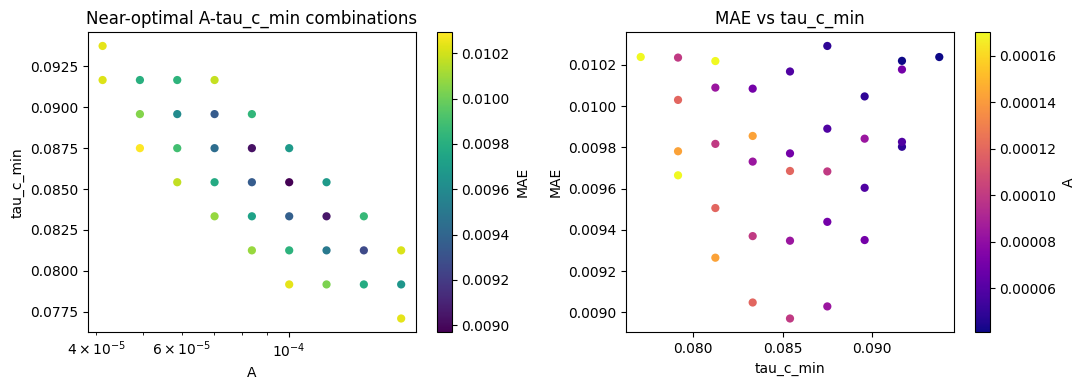

In [60]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.15

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "parameter_sensitivity_analysis/2iteration_field_parameter_sets_within10pct_MAE.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["tau_c_min"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("tau_c_min")
    axes[0].set_title("Near-optimal A-tau_c_min combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["tau_c_min"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("tau_c_min")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs tau_c_min")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()

Third Iteration

In [61]:
# start, stop, number of values
A_vals = np.logspace(-4, -3, 40) # values evenly spaced on log scale
tauc_min_vals = np.linspace(0.07, 0.09, 25)

In [62]:
calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min_vals=tauc_min_vals,
    A_vals=A_vals,
    B_vals=[B_vals],
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing tau_c_min = 7.000000e-02 (1/25)
Testing A = 1.000000e-04 (1/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.060818e-04 (2/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.125336e-04 (3/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.193777e-04 (4/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.266380e-04 (5/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.343399e-04 (6/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.425103e-04 (7/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.511775e-04 (8/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.603719e-04 (9/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.701254e-04 (10/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.804722e-04 (11/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 1.914482e-04 (12/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 2.030918e-04 (13/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 2.154435e-04 (14/40)
Testing B = 8.686600e+00 (1/1)
Testing A = 2.285464e-04 (15/40)
Testing B = 8.686600e+00 (1/1)
Testing A

Best MAE: 0.008973
10% threshold (<=): 0.009422
Parameter sets within threshold: 26 / 1000


,tau_c_min,A,B,MAE
0,0.085000,0.000106,8.6866,0.008973
1,0.084167,0.000113,8.6866,0.008986
2,0.085833,0.000100,8.6866,0.009035
3,0.085000,0.000100,8.6866,0.009038
4,0.083333,0.000119,8.6866,0.009047
5,0.084167,0.000106,8.6866,0.009079
6,0.082500,0.000127,8.6866,0.009127
7,0.083333,0.000113,8.6866,0.009137
8,0.083333,0.000127,8.6866,0.009191
9,0.084167,0.000100,8.6866,0.009197


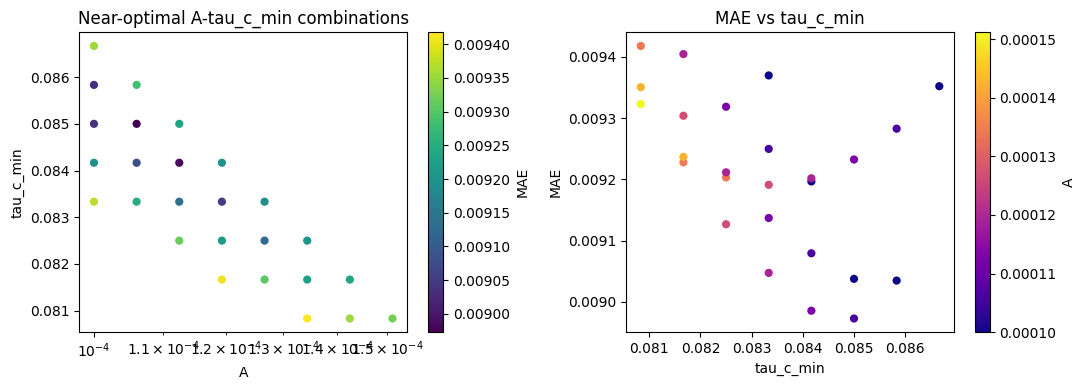

In [67]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)

mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.05

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "parameter_sensitivity_analysis/2iteration_field_parameter_sets_within10pct_MAE.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"A", "B", "tau_c_min"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["A"],
        near_optimal["tau_c_min"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("A")
    axes[0].set_ylabel("tau_c_min")
    axes[0].set_title("Near-optimal A-tau_c_min combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["tau_c_min"],
        near_optimal[mae_col],
        c=near_optimal["A"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("tau_c_min")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs tau_c_min")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("A")

    plt.tight_layout()
    plt.show()